# Career Copilot - HR data project

Going through this dataset to practice SQL, pandas, EDA, plotting, and a bit of ML (linear regression + 2 classification models).

Dataset: IBM's HR Attrition dataset, 1470 employees, one row per person.

## Imports

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import joblib
import plotly.express as px

pd.set_option("display.max_columns", None)

## Loading the data

In [2]:
df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.shape

(1470, 35)

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

## Cleaning

Going through the usual checks before doing anything else with it.

In [5]:
# any missing values?
df.isnull().sum().sum()

np.int64(0)

In [6]:
# any exact duplicate rows?
df.duplicated().sum()

np.int64(0)

Both 0, nice. Now checking if any column is just the same value for every row - if so it's useless and I'll drop it.

In [7]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col, "->", df[col].unique())

EmployeeCount -> [1]
Over18 -> <ArrowStringArray>
['Y']
Length: 1, dtype: str
StandardHours -> [80]


In [8]:
df = df.drop(columns=["EmployeeCount", "Over18", "StandardHours"])
df.shape

(1470, 32)

Quick look at the categorical columns, just to make sure there's no weird typos or inconsistent casing (e.g. 'Male' vs 'male').

In [9]:
for col in df.select_dtypes(include="object").columns:
    print(col, df[col].unique())

Attrition <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
BusinessTravel <ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str
Department <ArrowStringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str
EducationField <ArrowStringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str
Gender <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
JobRole <ArrowStringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str
MaritalStatus <ArrowStringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str
OverTime <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


/var/folders/py/nqkljkzx2kgdjw_69xjsd9qc0000gn/T/ipykernel_55862/2490523665.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


All fine. Let's also check that the rating-style columns (satisfaction, performance etc) actually stay within their documented 1-4 range.

In [10]:
rating_cols = ["JobSatisfaction", "EnvironmentSatisfaction", "WorkLifeBalance", "PerformanceRating"]
for col in rating_cols:
    print(col, "min:", df[col].min(), "max:", df[col].max())

JobSatisfaction min: 1 max: 4
EnvironmentSatisfaction min: 1 max: 4
WorkLifeBalance min: 1 max: 4
PerformanceRating min: 3 max: 4


Good, nothing out of range. Renaming columns to snake_case because I find ALLCaps/CamelCase annoying to type repeatedly.

In [11]:
def to_snake_case(name):
    out = ""
    for char in name:
        if char.isupper() and out:
            out += "_" + char.lower()
        else:
            out += char.lower()
    return out

df.columns = [to_snake_case(c) for c in df.columns]
df.columns.tolist()

['age',
 'attrition',
 'business_travel',
 'daily_rate',
 'department',
 'distance_from_home',
 'education',
 'education_field',
 'employee_number',
 'environment_satisfaction',
 'gender',
 'hourly_rate',
 'job_involvement',
 'job_level',
 'job_role',
 'job_satisfaction',
 'marital_status',
 'monthly_income',
 'monthly_rate',
 'num_companies_worked',
 'over_time',
 'percent_salary_hike',
 'performance_rating',
 'relationship_satisfaction',
 'stock_option_level',
 'total_working_years',
 'training_times_last_year',
 'work_life_balance',
 'years_at_company',
 'years_in_current_role',
 'years_since_last_promotion',
 'years_with_curr_manager']

(wrote that as a function instead of one giant rename dict - same result, less typing, and it'll work if column names change later)

## Outliers check

Using IQR rule on a few money-related columns just to see if there's anything weird.

In [12]:
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for col in ["monthly_income", "daily_rate", "hourly_rate", "monthly_rate"]:
    print(col, count_outliers(df[col]))

monthly_income 114
daily_rate 0
hourly_rate 0
monthly_rate 0


monthly_income has some outliers by the IQR rule, but they're just senior employees who genuinely earn more - not a data error, so I'm leaving them in.

## Putting it into SQL

In [13]:
conn = sqlite3.connect(":memory:")
df.to_sql("employees", conn, index=False)
pd.read_sql("SELECT COUNT(*) FROM employees", conn)

,COUNT(*)
0,1470


Also making 2 small lookup tables for department and job role, mostly so I have something to practice JOINs on later.

In [14]:
departments = pd.DataFrame({"department_name": df["department"].unique()})
departments["department_id"] = range(1, len(departments) + 1)
departments.to_sql("departments", conn, index=False)

job_roles = df[["job_role", "department"]].drop_duplicates()
job_roles = job_roles.merge(departments, left_on="department", right_on="department_name")
job_roles = job_roles.rename(columns={"job_role": "job_role_name"})[["job_role_name", "department_id"]]
job_roles["job_role_id"] = range(1, len(job_roles) + 1)
job_roles.to_sql("job_roles", conn, index=False)

job_roles.head()

,job_role_name,department_id,job_role_id
0,Sales Executive,1,1
1,Research Scientist,2,2
2,Laboratory Technician,2,3
3,Manufacturing Director,2,4
4,Healthcare Representative,2,5


## SQL practice

Same queries that are in schema.sql, just running them here too so I can see the output as a dataframe.

**Filter** - overtime + low satisfaction people

In [15]:
pd.read_sql('''
    SELECT employee_number, job_role, job_satisfaction, over_time
    FROM employees
    WHERE over_time = 'Yes' AND job_satisfaction <= 2
''', conn)

,employee_number,job_role,job_satisfaction,over_time
0,10,Laboratory Technician,1,Yes
1,21,Research Scientist,2,Yes
2,33,Research Scientist,1,Yes
3,51,Research Scientist,1,Yes
4,68,Sales Executive,1,Yes
...,...,...,...,...
148,1998,Research Scientist,1,Yes
149,2021,Sales Representative,1,Yes
150,2053,Laboratory Technician,2,Yes
151,2055,Sales Executive,1,Yes


**Sort + limit** - top 10 earners

In [16]:
pd.read_sql('''
    SELECT employee_number, job_role, department, monthly_income
    FROM employees
    ORDER BY monthly_income DESC
    LIMIT 10
''', conn)

,employee_number,job_role,department,monthly_income
0,259,Manager,Research & Development,19999
1,1035,Research Director,Research & Development,19973
2,1191,Manager,Research & Development,19943
3,226,Manager,Research & Development,19926
4,787,Manager,Research & Development,19859
5,1282,Manager,Sales,19847
6,1038,Manager,Sales,19845
7,1740,Manager,Sales,19833
8,1255,Research Director,Research & Development,19740
9,1338,Manager,Human Resources,19717


**Group by + multiple aggregates** - attrition rate and income per department

In [17]:
dept_summary = pd.read_sql('''
    SELECT
        department,
        COUNT(*) AS headcount,
        ROUND(AVG(CASE WHEN attrition='Yes' THEN 1.0 ELSE 0 END), 3) AS attrition_rate,
        ROUND(AVG(monthly_income), 0) AS avg_income
    FROM employees
    GROUP BY department
    ORDER BY attrition_rate DESC
''', conn)
dept_summary

,department,headcount,attrition_rate,avg_income
0,Sales,446,0.206,6959.0
1,Human Resources,63,0.190,6655.0
2,Research & Development,961,0.138,6281.0


**Having** - job roles where avg tenure is under 4 years

In [18]:
pd.read_sql('''
    SELECT job_role, COUNT(*) AS headcount, ROUND(AVG(years_at_company),1) AS avg_tenure
    FROM employees
    GROUP BY job_role
    HAVING AVG(years_at_company) < 4
    ORDER BY avg_tenure
''', conn)

,job_role,headcount,avg_tenure
0,Sales Representative,83,2.9


**Case when** - bucket ages into groups

In [19]:
pd.read_sql('''
    SELECT
        CASE
            WHEN age < 30 THEN 'Under 30'
            WHEN age BETWEEN 30 AND 40 THEN '30-40'
            WHEN age BETWEEN 41 AND 50 THEN '41-50'
            ELSE '50+'
        END AS age_bracket,
        COUNT(*) AS headcount,
        ROUND(AVG(monthly_income), 0) AS avg_income
    FROM employees
    GROUP BY age_bracket
''', conn)

,age_bracket,headcount,avg_income
0,30-40,679,5776.0
1,41-50,322,9074.0
2,50+,143,10575.0
3,Under 30,326,3692.0


**Join** - job roles with their department name

In [20]:
pd.read_sql('''
    SELECT jr.job_role_name, d.department_name
    FROM job_roles jr
    JOIN departments d ON jr.department_id = d.department_id
    ORDER BY d.department_name
''', conn).head(10)

,job_role_name,department_name
0,Human Resources,Human Resources
1,Manager,Human Resources
2,Research Scientist,Research & Development
3,Laboratory Technician,Research & Development
4,Manufacturing Director,Research & Development
5,Healthcare Representative,Research & Development
6,Research Director,Research & Development
7,Manager,Research & Development
8,Sales Executive,Sales
9,Manager,Sales


**Subquery** - people earning above the overall average

In [21]:
above_avg = pd.read_sql('''
    SELECT employee_number, job_role, monthly_income
    FROM employees
    WHERE monthly_income > (SELECT AVG(monthly_income) FROM employees)
''', conn)
len(above_avg)

493

**Correlated subquery** - same thing but compared to each person's own department average instead of the company-wide one

In [22]:
pd.read_sql('''
    SELECT e.employee_number, e.department, e.monthly_income
    FROM employees e
    WHERE e.monthly_income > (
        SELECT AVG(e2.monthly_income) FROM employees e2 WHERE e2.department = e.department
    )
    ORDER BY e.department
''', conn).head(10)

,employee_number,department,monthly_income
0,140,Human Resources,18844
1,148,Human Resources,17328
2,590,Human Resources,9950
3,644,Human Resources,18200
4,698,Human Resources,10725
5,731,Human Resources,19141
6,734,Human Resources,19189
7,1098,Human Resources,10482
8,1338,Human Resources,19717
9,1352,Human Resources,14026


**CTE** - same idea as above, just written in a way that's easier to read

In [23]:
pd.read_sql('''
    WITH dept_avg AS (
        SELECT department, AVG(monthly_income) AS avg_income
        FROM employees
        GROUP BY department
    )
    SELECT e.employee_number, e.department, e.monthly_income, d.avg_income
    FROM employees e
    JOIN dept_avg d ON e.department = d.department
    WHERE e.monthly_income > d.avg_income
''', conn).head(10)

,employee_number,department,monthly_income,avg_income
0,12,Research & Development,9526,6281.252862
1,20,Research & Development,9980,6281.252862
2,23,Sales,15427,6959.172646
3,28,Research & Development,11994,6281.252862
4,32,Research & Development,19094,6281.252862
5,36,Research & Development,10248,6281.252862
6,38,Sales,18947,6959.172646
7,40,Research & Development,6465,6281.252862
8,56,Sales,8726,6959.172646
9,58,Research & Development,19545,6281.252862


**Window function** - rank people by income inside their own department

In [24]:
pd.read_sql('''
    SELECT employee_number, department, monthly_income,
           RANK() OVER (PARTITION BY department ORDER BY monthly_income DESC) AS rank_in_dept
    FROM employees
''', conn).query("rank_in_dept <= 3")

,employee_number,department,monthly_income,rank_in_dept
0,1338,Human Resources,19717,1
1,1625,Human Resources,19658,2
2,1973,Human Resources,19636,3
63,259,Research & Development,19999,1
64,1035,Research & Development,19973,2
65,1191,Research & Development,19943,3
1024,1282,Sales,19847,1
1025,1038,Sales,19845,2
1026,1740,Sales,19833,3


**View** - saving the satisfaction/attrition breakdown as a view so I don't have to retype the query

In [25]:
conn.execute('''
    CREATE VIEW v_satisfaction_attrition AS
    SELECT job_satisfaction, work_life_balance, attrition, COUNT(*) AS headcount
    FROM employees
    GROUP BY job_satisfaction, work_life_balance, attrition
''')
pd.read_sql("SELECT * FROM v_satisfaction_attrition LIMIT 10", conn)

,job_satisfaction,work_life_balance,attrition,headcount
0,1,1,No,9
1,1,1,Yes,8
2,1,2,No,48
3,1,2,Yes,13
4,1,3,No,143
5,1,3,Yes,39
6,1,4,No,23
7,1,4,Yes,6
8,2,1,No,14
9,2,1,Yes,4


## EDA / charts

Just looking at the data from a few angles before building anything.

In [26]:
df["attrition"].value_counts()

attrition
No     1233
Yes     237
Name: count, dtype: int64

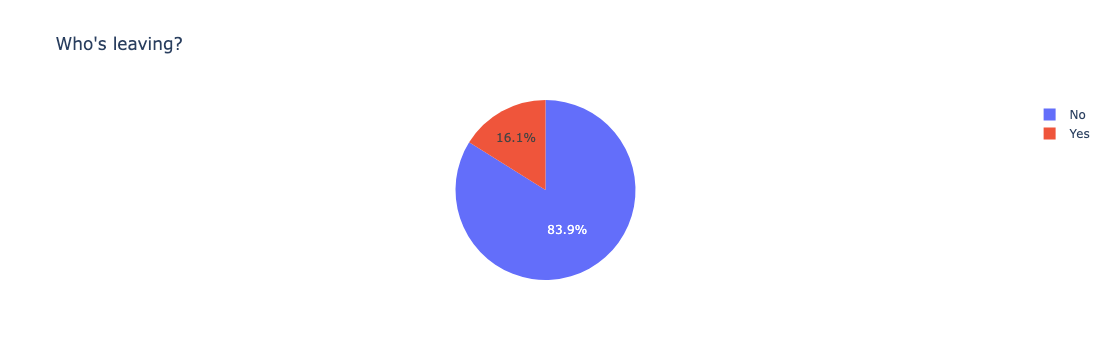

In [27]:
fig = px.pie(df, names="attrition", title="Who's leaving?")
fig.show()

About 16% left. Worth remembering - if I build a model that just guesses 'No' every time it'll already be 84% accurate, which sounds good but is useless.

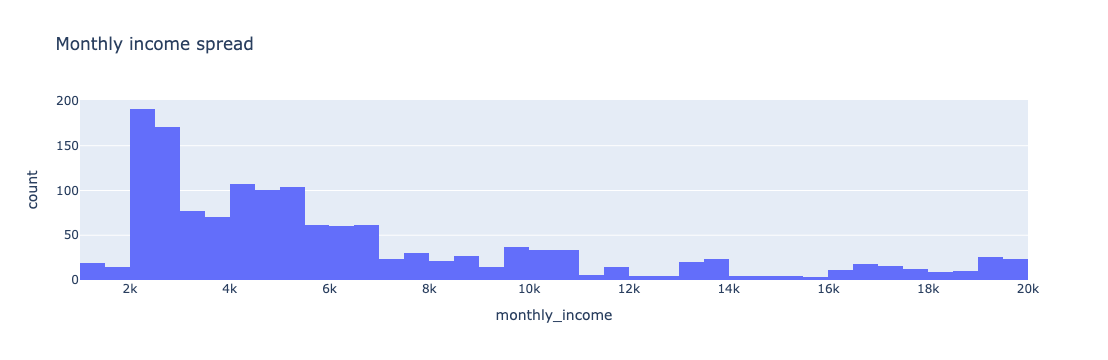

In [28]:
fig = px.histogram(df, x="monthly_income", nbins=40, title="Monthly income spread")
fig.show()

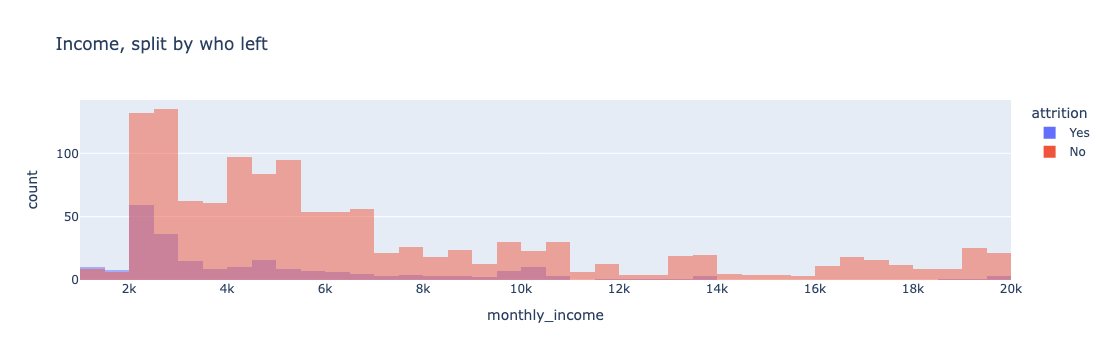

In [29]:
fig = px.histogram(df, x="monthly_income", color="attrition", barmode="overlay", nbins=40,
                    title="Income, split by who left")
fig.show()

People who left skew toward lower income - makes sense.

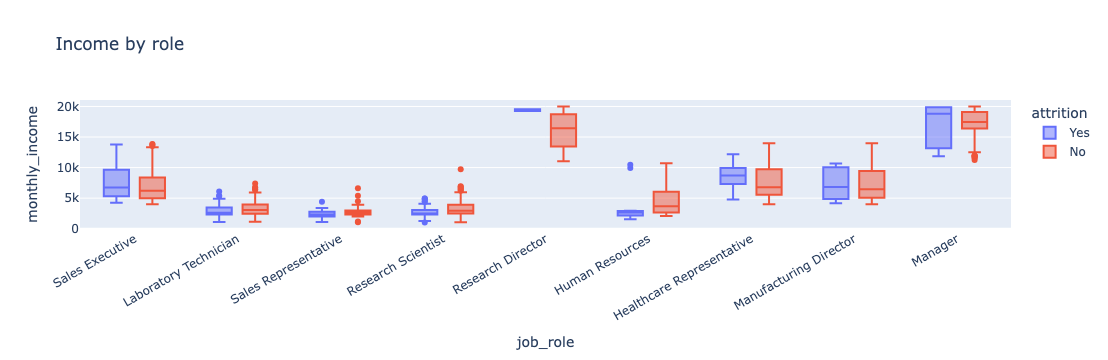

In [30]:
fig = px.box(df, x="job_role", y="monthly_income", color="attrition", title="Income by role")
fig.update_layout(xaxis_tickangle=-30)
fig.show()

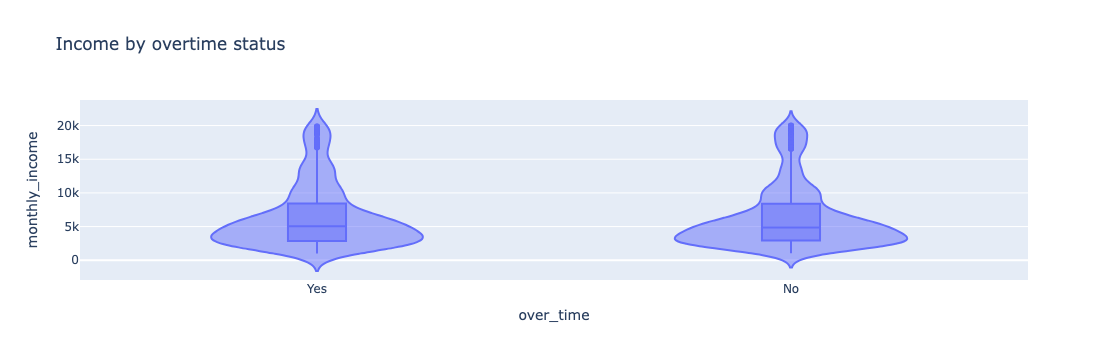

In [31]:
fig = px.violin(df, x="over_time", y="monthly_income", box=True, title="Income by overtime status")
fig.show()

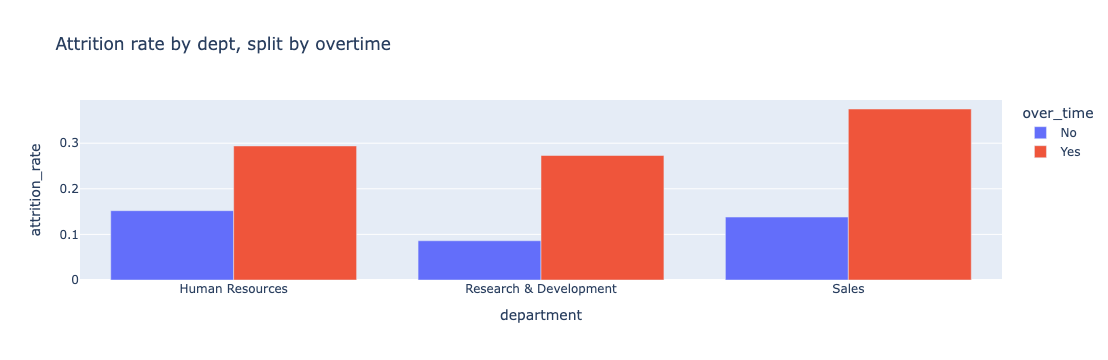

In [32]:
overtime_dept = pd.read_sql('''
    SELECT department, over_time, COUNT(*) AS n,
           ROUND(AVG(CASE WHEN attrition='Yes' THEN 1.0 ELSE 0 END),3) AS attrition_rate
    FROM employees GROUP BY department, over_time
''', conn)

fig = px.bar(overtime_dept, x="department", y="attrition_rate", color="over_time", barmode="group",
             title="Attrition rate by dept, split by overtime")
fig.show()

Overtime makes attrition worse in every department, not just one or two - that's a pretty consistent pattern.

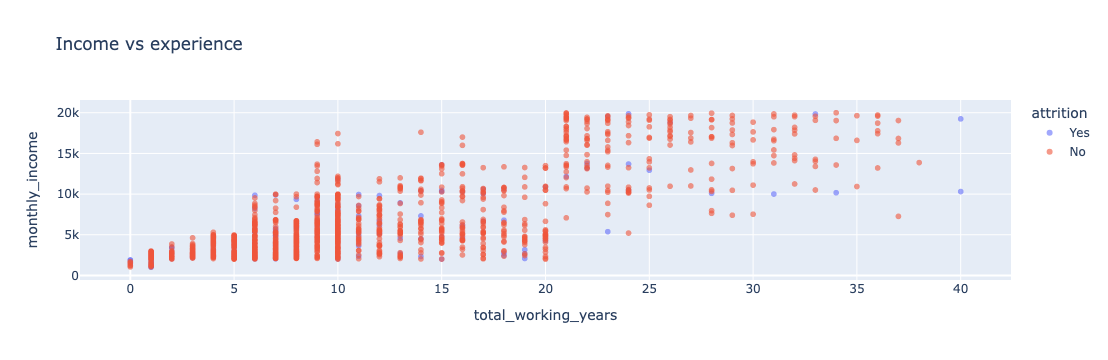

In [33]:
fig = px.scatter(df, x="total_working_years", y="monthly_income", color="attrition",
                  title="Income vs experience", opacity=0.6)
fig.show()

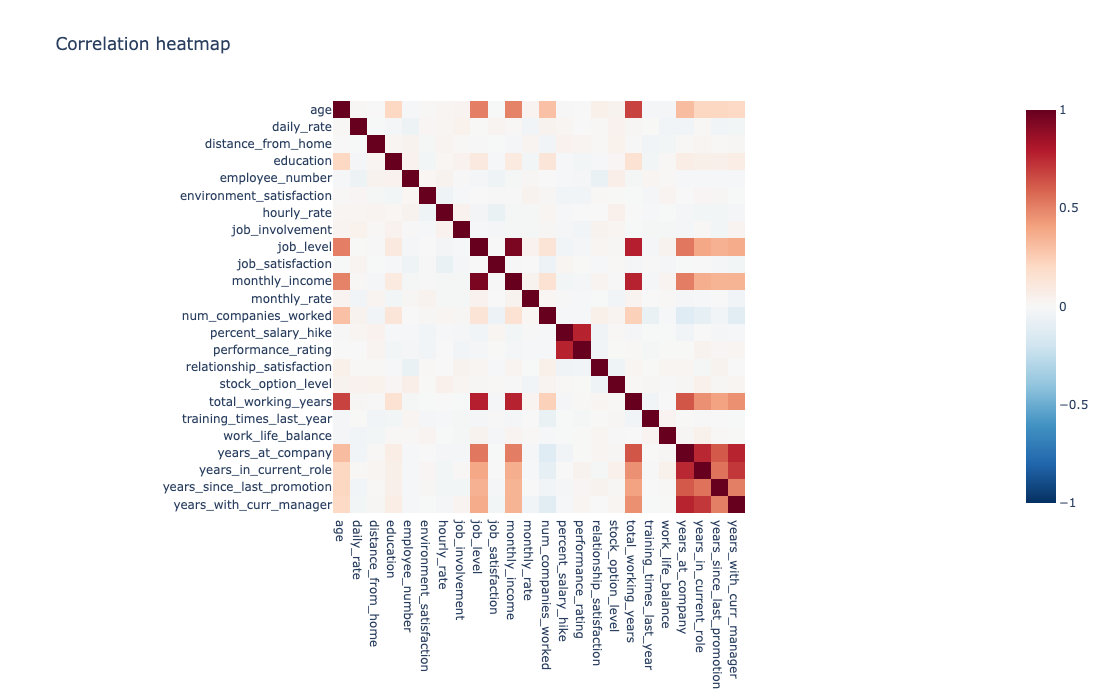

In [34]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
fig = px.imshow(corr, color_continuous_scale="RdBu_r", zmin=-1, zmax=1, title="Correlation heatmap")
fig.update_layout(height=700)
fig.show()

In [35]:
corr["monthly_income"].sort_values(key=abs, ascending=False).head(8)

monthly_income                1.000000
job_level                     0.950300
total_working_years           0.772893
years_at_company              0.514285
age                           0.497855
years_in_current_role         0.363818
years_since_last_promotion    0.344978
years_with_curr_manager       0.344079
Name: monthly_income, dtype: float64

job_level correlates super strongly with income (0.95) - makes sense, that's basically what determines pay level.

## Feature engineering

Adding a couple of extra columns and the two things I'll actually try to predict later.

In [36]:
clean = df.copy()
clean["attrition_flag"] = (clean["attrition"] == "Yes").astype(int)

# "stuck" = longer than the typical gap since their last promotion
median_gap = clean["years_since_last_promotion"].median()
clean["stagnation_flag"] = (clean["years_since_last_promotion"] > median_gap).astype(int)

clean["attrition_flag"].mean(), clean["stagnation_flag"].mean()

(np.float64(0.16122448979591836), np.float64(0.3619047619047619))

Important thing to remember: stagnation_flag is literally built from years_since_last_promotion. So later when I try to predict stagnation_flag, I have to remove years_since_last_promotion from the inputs - otherwise the model just looks up its own answer, which would be cheating (and would show up as a suspiciously perfect score).

In [37]:
clean["satisfaction_index"] = clean[
    ["environment_satisfaction", "job_satisfaction", "relationship_satisfaction", "work_life_balance"]
].mean(axis=1)
clean["is_overtime"] = (clean["over_time"] == "Yes").astype(int)

clean.to_csv("data/employees_clean.csv", index=False)
clean.shape

(1470, 36)

## ML #1: Linear Regression - predicting income

Trying to predict monthly_income from age, job level, experience etc. Picked income because the scatter plot above showed a pretty clean linear-ish relationship with experience/job level, so linear regression should actually do well here.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [39]:
cat_cols = ["department", "job_role", "education_field", "marital_status", "gender"]
num_cols = ["age", "job_level", "total_working_years", "years_at_company", "education"]

X = clean[cat_cols + num_cols]
y = clean["monthly_income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Quick function to build a model pipeline - just so I don't repeat the same 4 lines for every model I try later in the notebook.

In [40]:
def build_pipeline(model, cat_cols, num_cols):
    prep = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ])
    return Pipeline([("prep", prep), ("model", model)])

In [41]:
income_model = build_pipeline(LinearRegression(), cat_cols, num_cols)
income_model.fit(X_train, y_train)

preds = income_model.predict(X_test)
print("R2:", round(r2_score(y_test, preds), 3))
print("Average error: $", round(mean_absolute_error(y_test, preds)))

R2: 0.937
Average error: $ 895


R2 of ~0.93 is honestly better than I expected - means the model explains most of the variation in income just from level + experience + a few other things. Makes sense though, pay is mostly determined by job level.

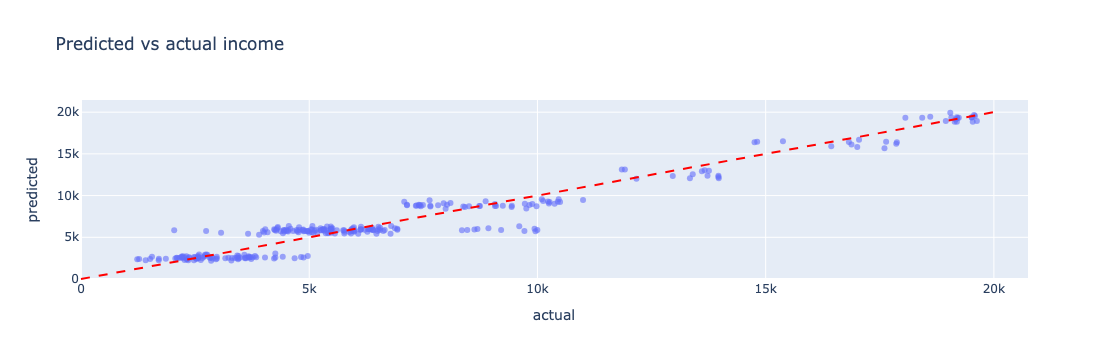

In [42]:
results = pd.DataFrame({"actual": y_test, "predicted": preds})
fig = px.scatter(results, x="actual", y="predicted", title="Predicted vs actual income", opacity=0.6)
fig.add_shape(type="line", x0=0, y0=0, x1=20000, y1=20000, line=dict(color="red", dash="dash"))
fig.show()

Points hugging the red line = good. A perfect model would have every dot exactly on it.

In [43]:
# what's actually driving the prediction? look at the coefficients
feature_names = (
    list(income_model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_cols))
    + num_cols
)
coefs = income_model.named_steps["model"].coef_

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs}).sort_values("coef", key=abs, ascending=False)
coef_df.head(10)

,feature,coef
6,job_role_Manager,3486.462405
24,job_level,3112.933235
8,job_role_Research Director,3041.908622
5,job_role_Laboratory Technician,-1360.303442
9,job_role_Research Scientist,-1252.611733
11,job_role_Sales Representative,-1083.190533
3,job_role_Healthcare Representative,-891.131353
7,job_role_Manufacturing Director,-879.734235
4,job_role_Human Resources,-533.636864
10,job_role_Sales Executive,-527.762866


job_level has by far the biggest coefficient, which lines up with the correlation heatmap from earlier.

## ML 2 + 3: Predicting attrition and stagnation

Two yes/no questions:
- will this person leave? (attrition_flag)
- is this person stuck without a promotion? (stagnation_flag)

Both are classification, so I'm reusing pretty much the same setup, just with a classifier instead of LinearRegression, and trying a couple of different models to compare.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

Wrapping the training step in a function since I'm doing the exact same thing twice (once for attrition, once for stagnation) and didn't want to copy-paste the whole block. Also added a try/except around the actual model fit - if a model ever fails to converge or throws an error on weird data, I'd rather get a clear message than the whole notebook crashing.

(side note: I originally split categorical vs numeric columns with `clean[c].dtype == "object"`, which is what most examples online use. It silently picked up zero categorical columns here and everything blew up with a "could not convert string to float" error - turns out this pandas version stores text columns as a string dtype, not object, so that check just doesn't work anymore. Swapped to `pd.api.types.is_numeric_dtype()` instead, which checks it the other way around and doesn't care which dtype pandas happens to use for text.)

In [45]:
def train_and_score(target_col, feature_cols, label):
    X = clean[feature_cols]
    y = clean[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # split into categorical vs numeric columns. tried using `dtype == "object"`
    # for this at first but it didn't work - turns out this pandas version
    # stores text columns as a string dtype, not object. is_numeric_dtype
    # is more reliable: anything NOT numeric, treat as categorical.
    cat = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(clean[c])]
    num = [c for c in feature_cols if c not in cat]

    models = {
        "logistic regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "random forest": RandomForestClassifier(n_estimators=200, max_depth=8,
                                                  class_weight="balanced", random_state=42),
    }

    fitted = {}
    print(f"--- {label} ---")
    for name, model in models.items():
        try:
            pipe = build_pipeline(model, cat, num)
            pipe.fit(X_train, y_train)
            proba = pipe.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, proba)
            print(f"{name}: ROC-AUC = {round(auc, 3)}")
            fitted[name] = pipe
        except Exception as e:
            print(f"{name} failed: {e}")

    return fitted, X_test, y_test

**Attrition model.** Using a decent chunk of the columns as features.

In [46]:
attrition_features = ["department", "job_role", "marital_status", "age", "monthly_income",
                       "job_satisfaction", "environment_satisfaction", "work_life_balance",
                       "years_at_company", "total_working_years", "is_overtime",
                       "num_companies_worked", "satisfaction_index"]

attrition_models, attr_Xtest, attr_ytest = train_and_score(
    "attrition_flag", attrition_features, "Attrition"
)

--- Attrition ---
logistic regression: ROC-AUC = 0.78
random forest: ROC-AUC = 0.762


In [47]:
best = attrition_models["logistic regression"]
preds = best.predict(attr_Xtest)
print(classification_report(attr_ytest, preds))

              precision    recall  f1-score   support

           0       0.93      0.72      0.81       247
           1       0.33      0.70      0.45        47

    accuracy                           0.72       294
   macro avg       0.63      0.71      0.63       294
weighted avg       0.83      0.72      0.75       294



ROC-AUC around 0.77-0.8, which is decent but not amazing - and honestly that's expected. Attrition is a minority class (~16%) and people leave jobs for all kinds of reasons that aren't in this spreadsheet (better offer elsewhere, family stuff, etc), so I wouldn't trust a model that claimed to nail this perfectly.

**Stagnation model.** Same idea, but I have to leave out years_since_last_promotion since that's literally what the label is built from.

In [48]:
stagnation_features = ["department", "job_role", "marital_status", "age", "monthly_income",
                        "job_satisfaction", "years_at_company", "years_in_current_role",
                        "years_with_curr_manager", "total_working_years", "is_overtime",
                        "training_times_last_year", "satisfaction_index"]
# (years_since_last_promotion deliberately NOT included - that's the leakage column)

stagnation_models, stag_Xtest, stag_ytest = train_and_score(
    "stagnation_flag", stagnation_features, "Stagnation"
)

--- Stagnation ---
logistic regression: ROC-AUC = 0.745
random forest: ROC-AUC = 0.883


In [49]:
best_stag = stagnation_models["random forest"]
preds = best_stag.predict(stag_Xtest)
print(classification_report(stag_ytest, preds))

              precision    recall  f1-score   support

           0       0.90      0.81      0.85       188
           1       0.71      0.85      0.78       106

    accuracy                           0.82       294
   macro avg       0.81      0.83      0.81       294
weighted avg       0.84      0.82      0.83       294



Better balance here, makes sense - tenure/role-stability features are pretty informative about whether someone's been sitting still.

Just to double check the leakage thing isn't just theoretical - if I add years_since_last_promotion back into the stagnation features and rerun, watch what happens:

In [50]:
leaky_features = stagnation_features + ["years_since_last_promotion"]
leaky_models, leaky_Xtest, leaky_ytest = train_and_score(
    "stagnation_flag", leaky_features, "Stagnation (WITH the leak, for comparison)"
)

--- Stagnation (WITH the leak, for comparison) ---
logistic regression: ROC-AUC = 1.0
random forest: ROC-AUC = 1.0


Yep - ROC-AUC jumps to basically 1.0. That's not a better model, that's the model finding its own answer key. Good reminder to always think about where a target variable actually comes from before throwing every column at a model.

## Feature importance

What's actually driving the random forest's stagnation predictions?

In [51]:
def show_importance(pipe, cat_cols, num_cols, top_n=10):
    names = list(pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_cols)) + num_cols
    importances = pipe.named_steps["model"].feature_importances_
    out = pd.DataFrame({"feature": names, "importance": importances})
    return out.sort_values("importance", ascending=False).head(top_n)

stag_cat = [c for c in stagnation_features if not pd.api.types.is_numeric_dtype(clean[c])]
stag_num = [c for c in stagnation_features if c not in stag_cat]
fi = show_importance(best_stag, stag_cat, stag_num)
fi

,feature,importance
18,years_at_company,0.301057
19,years_in_current_role,0.164372
20,years_with_curr_manager,0.116801
16,monthly_income,0.081407
21,total_working_years,0.077488
15,age,0.073213
24,satisfaction_index,0.037636
23,training_times_last_year,0.029718
17,job_satisfaction,0.017077
22,is_overtime,0.010646


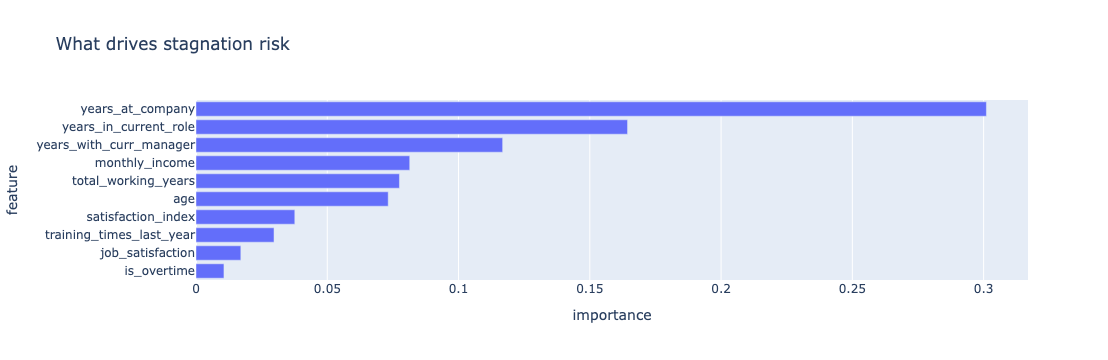

In [52]:
fig = px.bar(fi.sort_values("importance"), x="importance", y="feature", orientation="h",
             title="What drives stagnation risk")
fig.show()

## Saving models for the streamlit app

In [56]:
import os
os.makedirs('models', exist_ok=True)
joblib.dump(income_model, "models/income_model.joblib")
joblib.dump(best, "models/attrition_model.joblib")
joblib.dump(best_stag, "models/stagnation_model.joblib")

joblib.dump({"cat": cat_cols, "num": num_cols}, "models/income_features.joblib")
joblib.dump({"features": attrition_features}, "models/attrition_features.joblib")
joblib.dump({"features": stagnation_features}, "models/stagnation_features.joblib")

print("saved")

saved


Quick test that the saved models actually load back and work, before moving to the streamlit app.

In [57]:
try:
    test_model = joblib.load("models/income_model.joblib")
    sample = clean[cat_cols + num_cols].iloc[[0]]
    pred = test_model.predict(sample)[0]
    print(f"Loaded OK, predicted income for first row: ${pred:,.0f} (actual: ${clean.iloc[0]['monthly_income']:,})")
except FileNotFoundError:
    print("model file not found - did the save step run?")
except Exception as e:
    print("something else went wrong:", e)

Loaded OK, predicted income for first row: $5,807 (actual: $5,993)
